# Model Training & Evaluation
## Goal: Train Random Forest, evaluate performance, save model

This notebook shows the complete ML training pipeline with 
full metrics, confusion matrix, feature importance, and RUL prediction.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import roc_curve, auc
from train_model import train_test_split_time, train_random_forest, train_logistic_regression, evaluate_model, save_model
from features import get_feature_columns

df = pd.read_csv('../data/processed/processed_data.csv')
feature_cols = get_feature_columns(df)
print(f"Loaded processed data: {df.shape}")
print(f"Features: {len(feature_cols)}")

✅ Total features for model: 60
Loaded processed data: (22025, 64)
Features: 60


In [2]:
# ── Train/test split ──
X_train, X_test, y_train, y_test = train_test_split_time(df, feature_cols)
print(f"\nClass balance in training set:")
print(y_train.value_counts())
print(f"\nClass balance in test set:")
print(y_test.value_counts())

✅ Train: 17301 samples | Test: 4724 samples
   Train engines: 80 | Test engines: 20

Class balance in training set:
failure_label
0    14821
1     2480
Name: count, dtype: int64

Class balance in test set:
failure_label
0    4104
1     620
Name: count, dtype: int64


In [3]:
# ── Train models ──
rf_model = train_random_forest(X_train, y_train)
lr_model = train_logistic_regression(X_train, y_train)
print("\n✅ Both models trained!")


🌲 Training Random Forest Classifier...
✅ Random Forest trained!

📈 Training Logistic Regression (baseline)...
✅ Logistic Regression trained!

✅ Both models trained!


In [4]:
# ── Evaluate ──
y_pred_rf, y_proba_rf, cm_rf = evaluate_model(rf_model, X_test, y_test, "Random Forest")
y_pred_lr, y_proba_lr, cm_lr = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")


📊 Random Forest Evaluation Results
  Accuracy  : 0.9716
  Precision : 0.8302
  Recall    : 0.9855  ← Most important!
  F1 Score  : 0.9012
  AUC-ROC   : 0.9977

Detailed Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98      4104
     Failure       0.83      0.99      0.90       620

    accuracy                           0.97      4724
   macro avg       0.91      0.98      0.94      4724
weighted avg       0.98      0.97      0.97      4724


📊 Logistic Regression Evaluation Results
  Accuracy  : 0.9558
  Precision : 0.7503
  Recall    : 0.9935  ← Most important!
  F1 Score  : 0.8550
  AUC-ROC   : 0.9974

Detailed Report:
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97      4104
     Failure       0.75      0.99      0.85       620

    accuracy                           0.96      4724
   macro avg       0.87      0.97      0.91      4724
weighted avg       0.97      0.96      

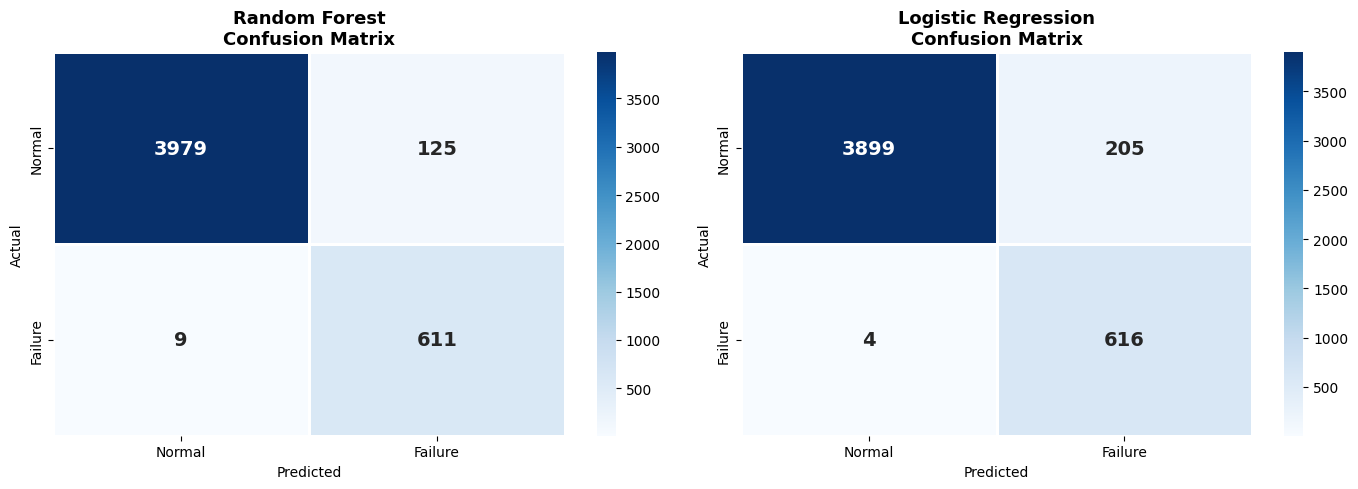

✅ Saved confusion matrix comparison


In [5]:
# ── Side-by-side confusion matrices ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, title in zip(axes, [cm_rf, cm_lr], 
                          ['Random Forest', 'Logistic Regression']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Failure'],
                yticklabels=['Normal','Failure'],
                linewidths=2, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{title}\nConfusion Matrix', fontweight='bold', fontsize=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../outputs/confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved confusion matrix comparison")

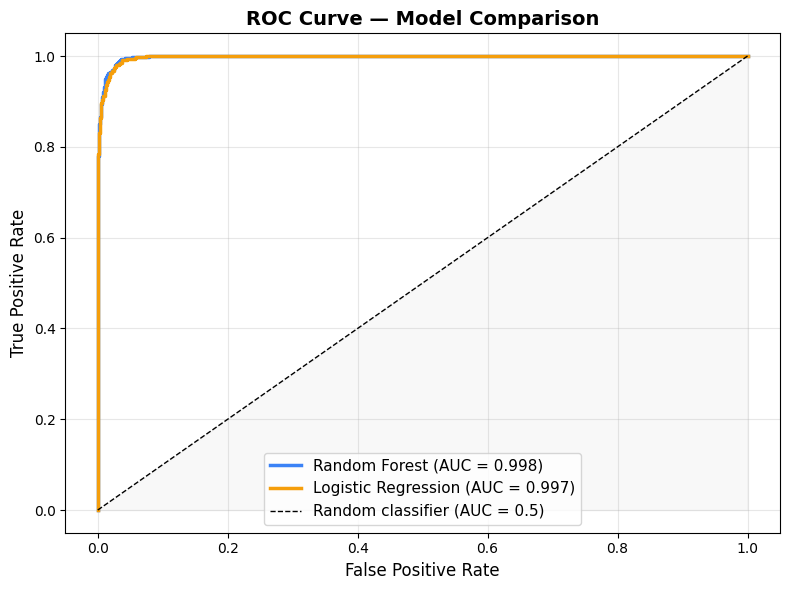

✅ ROC curve saved


In [6]:
# ── ROC Curve comparison ──
fig, ax = plt.subplots(figsize=(8, 6))

for proba, name, color in [(y_proba_rf, 'Random Forest', '#3b82f6'),
                            (y_proba_lr, 'Logistic Regression', '#f59e0b')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier (AUC = 0.5)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curve saved")

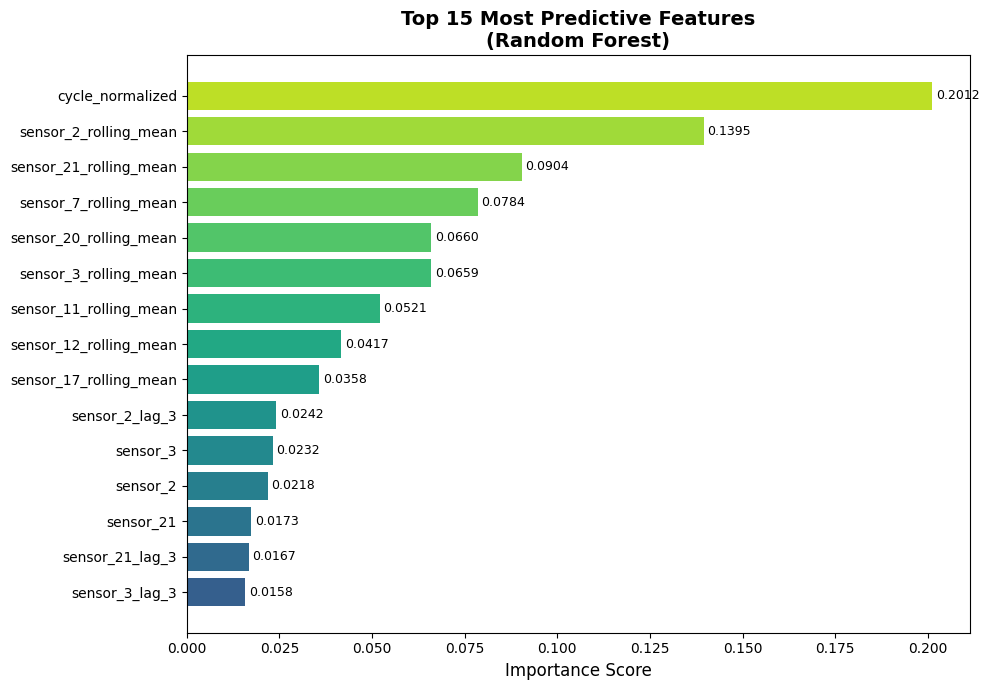

✅ Feature importance saved


In [7]:
# ── Feature importance ──
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
               color=plt.cm.viridis(np.linspace(0.3, 0.9, 15)))
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 15 Most Predictive Features\n(Random Forest)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, fi_df['importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance saved")

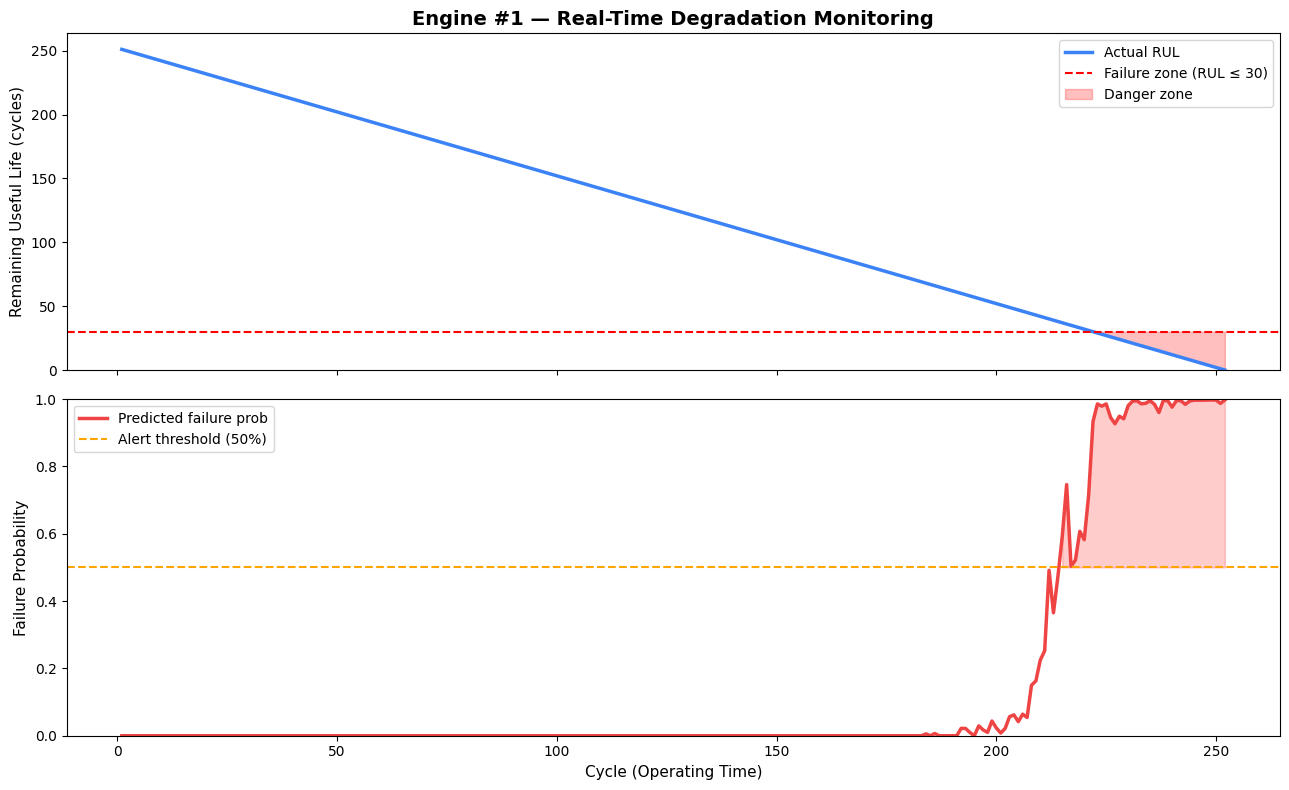

✅ RUL prediction curve saved — this is your BEST demo visual!


In [8]:
# ── RUL Prediction Curve for Engine 1 ──
engine_df = df[df['unit_id'] == 1].sort_values('cycle').copy()
X_eng = engine_df[feature_cols]
proba_eng = rf_model.predict_proba(X_eng)[:, 1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax1.plot(engine_df['cycle'], engine_df['RUL'], color='#3b82f6', linewidth=2.5, label='Actual RUL')
ax1.axhline(30, color='red', linestyle='--', linewidth=1.5, label='Failure zone (RUL ≤ 30)')
ax1.fill_between(engine_df['cycle'], engine_df['RUL'], 30,
                 where=engine_df['RUL'] <= 30, alpha=0.25, color='red', label='Danger zone')
ax1.set_ylabel('Remaining Useful Life (cycles)', fontsize=11)
ax1.set_title('Engine #1 — Real-Time Degradation Monitoring', fontsize=14, fontweight='bold')
ax1.legend(); ax1.set_ylim(bottom=0)

ax2.plot(engine_df['cycle'], proba_eng, color='#ef4444', linewidth=2.5, label='Predicted failure prob')
ax2.axhline(0.5, color='orange', linestyle='--', linewidth=1.5, label='Alert threshold (50%)')
ax2.fill_between(engine_df['cycle'], proba_eng, 0.5,
                 where=proba_eng >= 0.5, alpha=0.2, color='red')
ax2.set_xlabel('Cycle (Operating Time)', fontsize=11)
ax2.set_ylabel('Failure Probability', fontsize=11)
ax2.set_ylim(0, 1); ax2.legend()

plt.tight_layout()
plt.savefig('../outputs/rul_prediction_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ RUL prediction curve saved — this is your BEST demo visual!")

In [9]:
# ── Save the trained model ──
import os
os.makedirs('../models', exist_ok=True)
save_model(rf_model, '../models/random_forest_model.pkl')
joblib.dump(feature_cols, '../models/feature_columns.pkl')
print("✅ Model and feature list saved to models/")
print("\n🎉 TRAINING COMPLETE! Summary:")
print(f"   Best model     : Random Forest")
print(f"   Features used  : {len(feature_cols)}")

✅ Model saved to: ../models/random_forest_model.pkl
✅ Model and feature list saved to models/

🎉 TRAINING COMPLETE! Summary:
   Best model     : Random Forest
   Features used  : 60
